<a href="https://colab.research.google.com/github/mhaih/btl_xstk/blob/linear-regression/linear-regression/mlr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hồi quy tuyến tính bội

Reset thư mục, lấy dữ liệu đã làm sạch và cài đặt thư viện:

In [17]:
system("rm -rv btl_xstk", intern = TRUE)
rm(list = ls())
system("git clone https://github.com/mhaih/btl_xstk.git")
setwd("btl_xstk")
gpu_clean <- read.csv("cleaned_data/gpu_ready_for_models.csv")
install.packages("GGally")

Warning message in system("rm -rv btl_xstk", intern = TRUE):
“running command 'rm -rv btl_xstk' had status 1”


character(0)
attr(,"status")
[1] 1
attr(,"errmsg")
[1] "Resource temporarily unavailable"

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 1. Khởi tạo

Bỏ qua các biến phân loại

In [31]:
cols_to_ignore = c("Manufacturer", "Memory_Type", "Notebook_GPU")
gpu_filter <- gpu_clean[, !(names(gpu_clean) %in% cols_to_ignore)]

Còn lại:

In [32]:
names(gpu_filter)

[1] "Core_Speed"       "Max_Power"        "Memory"           "Memory_Bandwidth"
[5] "Memory_Speed"     "Memory_Bus"       "Process"          "ROPs"            
[9] "TMUs"

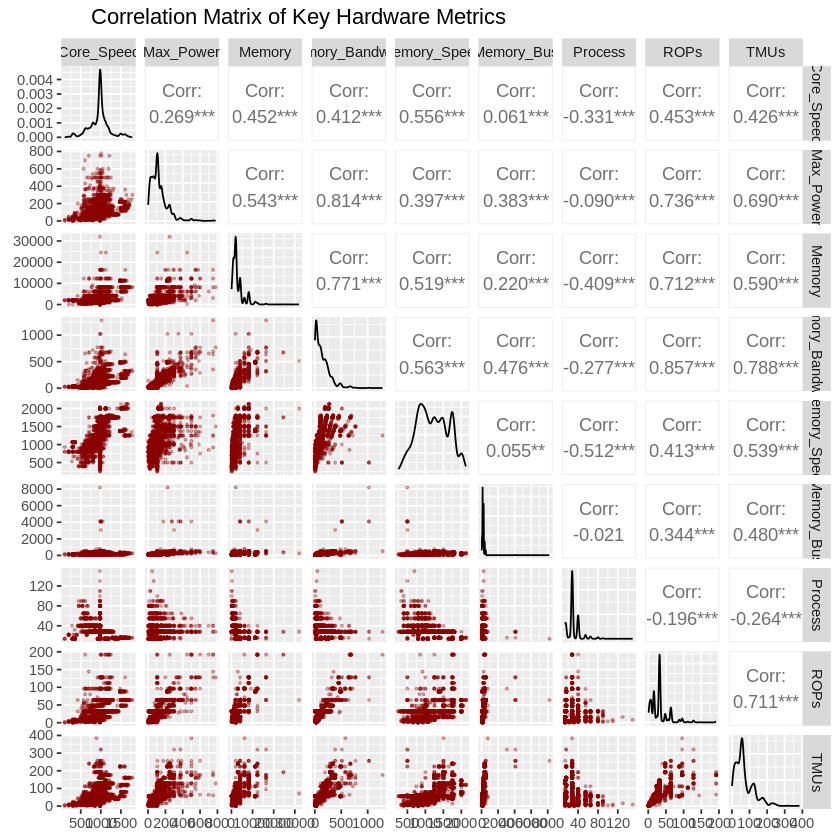

In [33]:
library(GGally)
p_pairs <- ggpairs(gpu_filter,
                   title = "     Correlation Matrix of Key Hardware Metrics",
                   lower = list(continuous = wrap("points", alpha = 0.3, size = 0.5, color = "darkred")))
print(p_pairs)

Mô hình:

$Max\_Power$

$=\beta_0+\beta_1*Core\_Speed+\beta_2*Max\_Power$

$+\beta_3*Memory+\beta_4*Memory\_Bandwidth+\beta_5*Memory\_Speed$

$+\beta_6*Memory\_Bus+\beta_7*Process+\beta_8*ROPs+\beta_9*TMUs$

In [34]:
base_model <- lm(Max_Power ~ Core_Speed + Memory + Memory_Bandwidth + Memory_Speed
                             + Memory_Bus + Process + ROPs + TMUs, data = gpu_filter)
base_model


Call:
lm(formula = Max_Power ~ Core_Speed + Memory + Memory_Bandwidth + 
    Memory_Speed + Memory_Bus + Process + ROPs + TMUs, data = gpu_filter)

Coefficients:
     (Intercept)        Core_Speed            Memory  Memory_Bandwidth  
       39.595009         -0.027187         -0.006362          0.571462  
    Memory_Speed        Memory_Bus           Process              ROPs  
       -0.004394         -0.030305          0.731992          0.521820  
            TMUs  
        0.306682  


## 2. Chẩn đoán mô hình

#### 2.1. Kiểm tra các giả định

Kiểm tra giả định phương sai hằng.

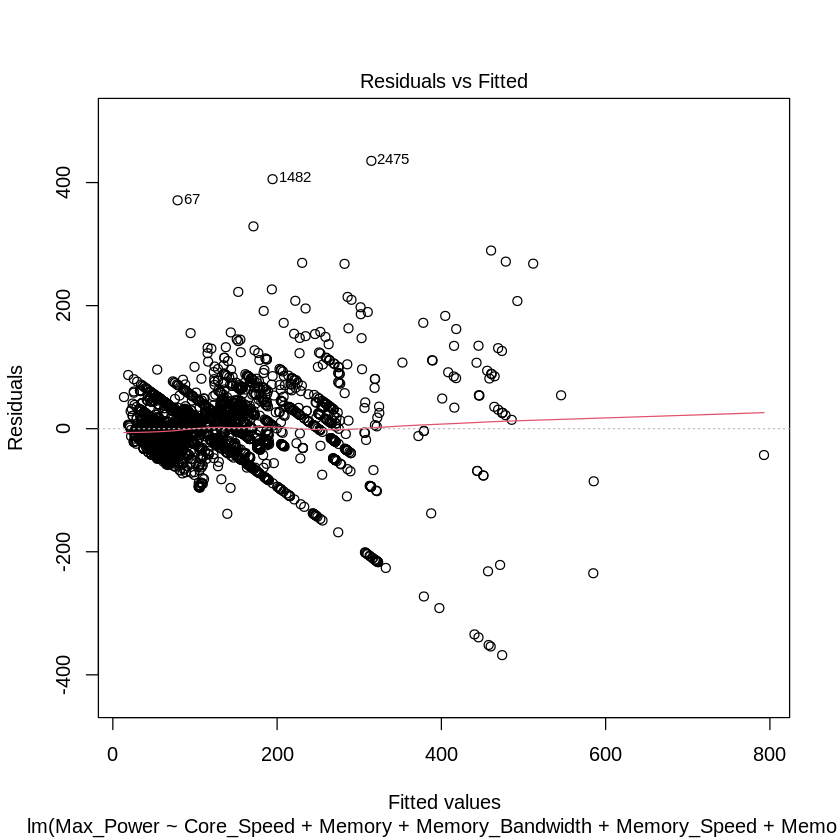

In [45]:
plot(base_model, which = 1)

In [38]:
summary(base_model)


Call:
lm(formula = Max_Power ~ Core_Speed + Memory + Memory_Bandwidth + 
    Memory_Speed + Memory_Bus + Process + ROPs + TMUs, data = gpu_filter)

Residuals:
    Min      1Q  Median      3Q     Max 
-368.01  -26.53   -2.36   23.76  435.25 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)      39.5950090  6.0866550   6.505 8.98e-11 ***
Core_Speed       -0.0271872  0.0048899  -5.560 2.92e-08 ***
Memory           -0.0063621  0.0005972 -10.653  < 2e-16 ***
Memory_Bandwidth  0.5714617  0.0191380  29.860  < 2e-16 ***
Memory_Speed     -0.0043939  0.0034949  -1.257    0.209    
Memory_Bus       -0.0303047  0.0045457  -6.667 3.07e-11 ***
Process           0.7319924  0.0878881   8.329  < 2e-16 ***
ROPs              0.5218203  0.0765412   6.818 1.10e-11 ***
TMUs              0.3066823  0.0315358   9.725  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 51.43 on 3170 degrees of freedom
Multiple R-square